# Trabalho - Bases Engenharia de Software VI - Inteligência Artificial 
# Predição de Qualidade de Vinhos com Redes Neurais
Professor: Marcio Andrey Roselli  
Estudante: Bianco Da Costa Oliveira

# Seção 1.1 - Análise Exploratória de Dados - Carregamento do Dataset

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

#Configuração de Hardware
device = torch.device("mps" if torch.backends.mps.is_available() else 
                     "cuda" if torch.cuda.is_available() else "cpu")

print(f"Executando em: {device}")

#Download do dataset 
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
try:
    df = pd.read_csv(url, sep=";")
    print(f"Dataset carregado com sucesso! Dimensões: {df.shape}")
except Exception as e:
    print(f"Erro ao carregar dados: {e}")

df.head()

Executando em: mps
Dataset carregado com sucesso! Dimensões: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


# Seção 1.2 - Análise Exploratória de Dados 

--- Verificação de Valores Ausentes ---
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Conclusão: O dataset não possui valores nulos.

--- Estatísticas Descritivas dos 11 atributos ---


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


/var/folders/gm/jwfmlvvn12d2lfg_vnjbf0dm0000gn/T/ipykernel_73813/3646335897.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='quality', ax=axes[0], palette='viridis')
/var/folders/gm/jwfmlvvn12d2lfg_vnjbf0dm0000gn/T/ipykernel_73813/3646335897.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='alvo', ax=axes[1], palette='coolwarm')
/var/folders/gm/jwfmlvvn12d2lfg_vnjbf0dm0000gn/T/ipykernel_73813/3646335897.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='sulphates', x='alvo', ax=axes[2], palett

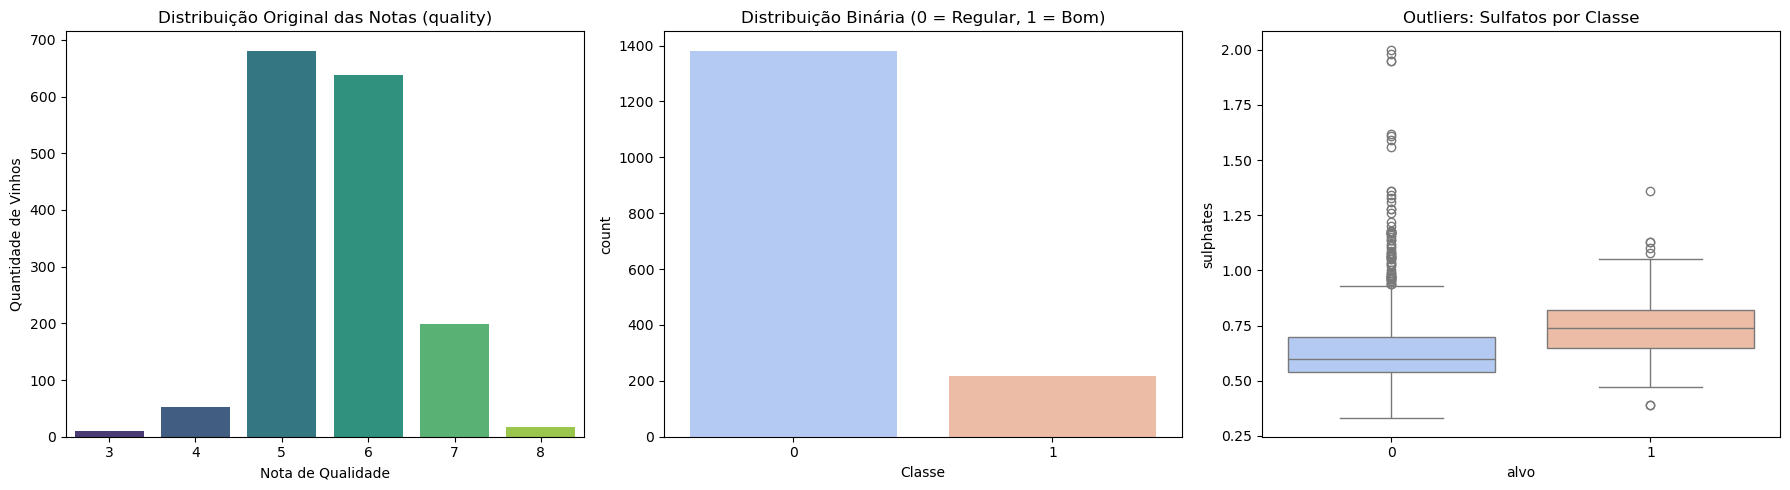

--- Correlação dos atributos com a classe 'Bom' (alvo) ---


/var/folders/gm/jwfmlvvn12d2lfg_vnjbf0dm0000gn/T/ipykernel_73813/3646335897.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlacoes.values, y=correlacoes.index, palette='RdBu_r', ax=ax_corr)


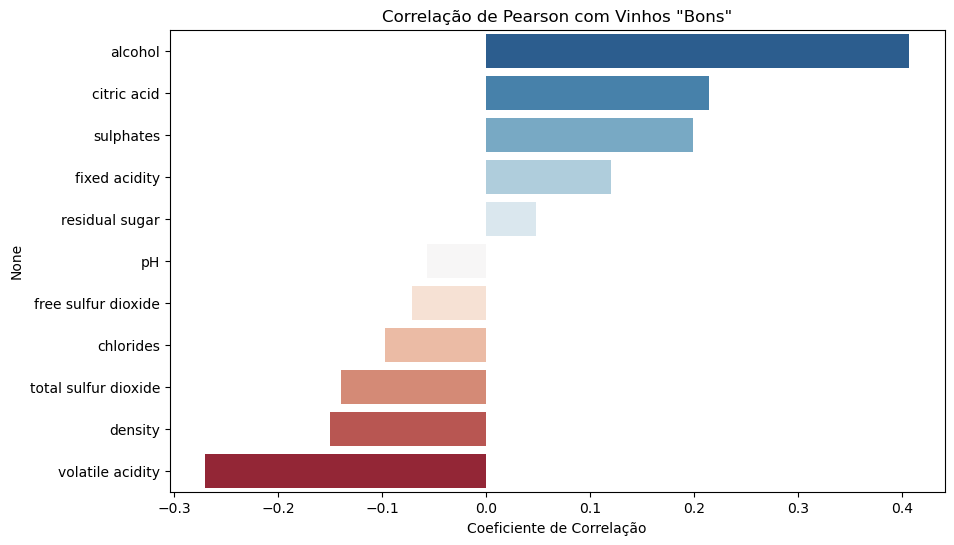

In [3]:
print("--- Verificação de Valores Ausentes ---")
print(df.isnull().sum())
print("\nConclusão: O dataset não possui valores nulos.\n")

print("--- Estatísticas Descritivas dos 11 atributos ---")
display(df.drop(columns=['quality']).describe().T)

# Vinho "bom" (quality >= 7) vs. "regular" (quality < 7)
df["alvo"] = (df["quality"] >= 7).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='quality', ax=axes[0], palette='viridis')
axes[0].set_title('Distribuição Original das Notas (quality)')
axes[0].set_xlabel('Nota de Qualidade')
axes[0].set_ylabel('Quantidade de Vinhos')

sns.countplot(data=df, x='alvo', ax=axes[1], palette='coolwarm')
axes[1].set_title('Distribuição Binária (0 = Regular, 1 = Bom)')
axes[1].set_xlabel('Classe')

sns.boxplot(data=df, y='sulphates', x='alvo', ax=axes[2], palette='coolwarm')
axes[2].set_title('Outliers: Sulfatos por Classe')

plt.tight_layout()
plt.show()

print("--- Correlação dos atributos com a classe 'Bom' (alvo) ---")
correlacoes = df.corr()['alvo'].drop(['quality', 'alvo']).sort_values(ascending=False)

fig_corr, ax_corr = plt.subplots(figsize=(10, 6))
sns.barplot(x=correlacoes.values, y=correlacoes.index, palette='RdBu_r', ax=ax_corr)
ax_corr.set_title('Correlação de Pearson com Vinhos "Bons"')
ax_corr.set_xlabel('Coeficiente de Correlação')
plt.show()

# Seção 2 - Pré-processamento de dados para modelagem futura

In [4]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

os.makedirs('../data/raw', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=";")
df.to_csv('../data/raw/winequality-red.csv', index=False)
print("Dados brutos salvos em '../data/raw/winequality-red.csv'")

df["alvo"] = (df["quality"] >= 7).astype(int)

X = df.drop(columns=['quality', 'alvo'])
y = df['alvo']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Divisão concluída: Treino ({X_train.shape[0]} amostras) | Teste ({X_test.shape[0]} amostras)")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"SMOTE aplicado. Nova distribuição do treino:\n{y_train_smote.value_counts()}")

X_train_scaled.to_csv('../data/processed/X_train_scaled.csv', index=False)
X_test_scaled.to_csv('../data/processed/X_test_scaled.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

X_train_smote.to_csv('../data/processed/X_train_smote.csv', index=False)
y_train_smote.to_csv('../data/processed/y_train_smote.csv', index=False)

print("Todos os dados processados foram salvos na pasta '../data/processed/'")

Dados brutos salvos em '../data/raw/winequality-red.csv'
Divisão concluída: Treino (1279 amostras) | Teste (320 amostras)
SMOTE aplicado. Nova distribuição do treino:
alvo
0    1105
1    1105
Name: count, dtype: int64
Todos os dados processados foram salvos na pasta '../data/processed/'


# Seção 3.1 - Modelagem de Dados - Resultado da Regressão Logística e Criação de Dataloaders (Baseline e Preparação PyTorch)

In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X_train = pd.read_csv('../data/processed/X_train_scaled.csv')
X_test = pd.read_csv('../data/processed/X_test_scaled.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

print("--- RESULTADOS DO BASELINE (REGRESSÃO LOGÍSTICA) ---")
baseline_model = LogisticRegression(class_weight='balanced', random_state=42)
baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)

print(classification_report(y_test, y_pred_base, target_names=['Regular (0)', 'Bom (1)']))

# Convertendo DataFrames/Arrays para Tensores PyTorch
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1) # Redimensionando para [N, 1]

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"\nDataLoaders criados. Batches de treino: {len(train_loader)}")

--- RESULTADOS DO BASELINE (REGRESSÃO LOGÍSTICA) ---
              precision    recall  f1-score   support

 Regular (0)       0.96      0.82      0.88       277
     Bom (1)       0.40      0.79      0.53        43

    accuracy                           0.81       320
   macro avg       0.68      0.80      0.71       320
weighted avg       0.89      0.81      0.84       320


DataLoaders criados. Batches de treino: 40


# Seção 3.2 - Rede Neural - Arquitetura, Treinamento e Avaliação

Treinando no dispositivo: mps

--- RESULTADOS DA REDE NEURAL ---
              precision    recall  f1-score   support

 Regular (0)       0.96      0.87      0.91       277
     Bom (1)       0.48      0.77      0.59        43

    accuracy                           0.86       320
   macro avg       0.72      0.82      0.75       320
weighted avg       0.90      0.86      0.87       320



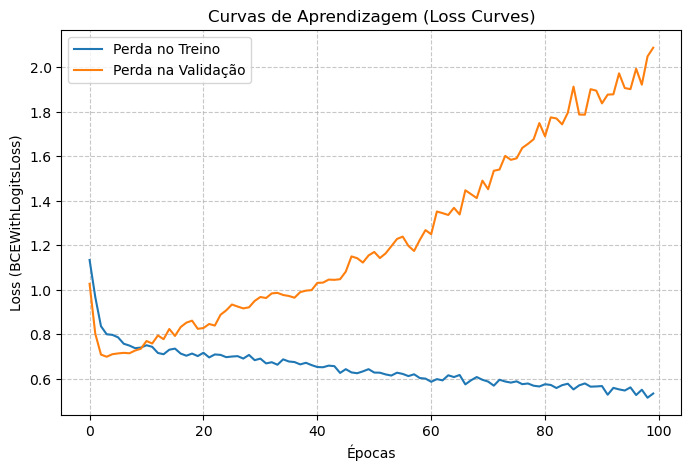

In [6]:

device = torch.device("mps" if torch.backends.mps.is_available() else 
                     "cuda" if torch.cuda.is_available() else "cpu")
print(f"Treinando no dispositivo: {device}\n")

class WineQualityNN(nn.Module):
    def __init__(self, input_size=11):
        super(WineQualityNN, self).__init__()
        self.layer1 = nn.Linear(input_size, 64)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3) 
        
        self.layer2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        
        self.output = nn.Linear(32, 1)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.layer1(x)))
        x = self.dropout2(self.relu2(self.layer2(x)))
        return self.output(x)

model = WineQualityNN().to(device)

num_negativos = (y_train == 0).sum()
num_positivos = (y_train == 1).sum()
peso_pos = torch.tensor([num_negativos / num_positivos], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=peso_pos)
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 100
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train() 
    batch_losses = []
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
        
    train_losses.append(np.mean(batch_losses))
    
    model.eval()
    with torch.no_grad():
        X_test_device = X_test_tensor.to(device)
        y_test_device = y_test_tensor.to(device)
        val_pred = model(X_test_device)
        val_loss = criterion(val_pred, y_test_device)
        val_losses.append(val_loss.item())

model.eval()
with torch.no_grad():
    y_pred_logits = model(X_test_device)
    y_pred_nn = (torch.sigmoid(y_pred_logits) >= 0.5).cpu().numpy().astype(int)

print("--- RESULTADOS DA REDE NEURAL ---")
print(classification_report(y_test, y_pred_nn, target_names=['Regular (0)', 'Bom (1)']))

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Perda no Treino')
plt.plot(val_losses, label='Perda na Validação')
plt.title('Curvas de Aprendizagem (Loss Curves)')
plt.xlabel('Épocas')
plt.ylabel('Loss (BCEWithLogitsLoss)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()